In [90]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split


In [91]:
california = fetch_california_housing()

In [92]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [93]:
california.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [94]:
print(f"Data: {california.data}")
print(f"Targets: {california.target}")

Data: [[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
Targets: [4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [95]:
# create dataset
X = pd.DataFrame(california.data, columns=california.feature_names)
X['Price'] = california.target

In [96]:
X.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [97]:
# check the dataset and see if there are any missing values
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [98]:
# describe the dataset
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


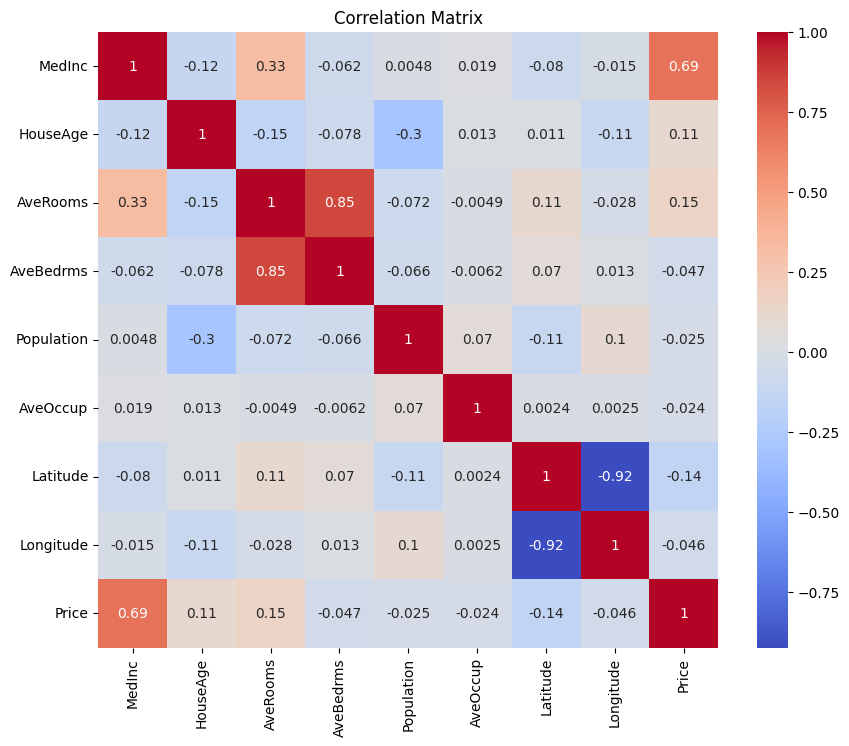

In [99]:
# plot the heatmap and pairplot
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# sns.pairplot(X)
# plt.title('Pairplot')
plt.show()

In [100]:
# divide the dataset into features and target variable
y = X['Price']
X = X.iloc[:, X.columns != 'Price']

In [101]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [102]:
# scaling of the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [103]:
# train the multiple linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# make predictions
y_pred = model.predict(X_test)
# evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

# adjusted r2 score
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print(f"Adjusted R^2 Score: {adjusted_r2}")

# print the coefficient and intercept
print(f"Coefficient: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Mean Squared Error: 0.5558915986952444
Mean Absolute Error: 0.5332001304956565
R^2 Score: 0.5757877060324508
Adjusted R^2 Score: 0.5749637928613558
Coefficient: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Intercept: 2.071946937378881


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# ===============================
# MAIN FUNCTION
# ===============================
def check_regression_assumptions(X, y, model):
    """
    X -> Features (DataFrame)
    y -> Target (Series)
    model -> Trained regression model
    """

    print("\n==============================")
    print("Checking Regression Assumptions")
    print("==============================\n")

    # Predictions & Residuals
    y_pred = model.predict(X)
    residuals = y - y_pred

    # 1. LINEARITY
    check_linearity(y_pred, residuals)

    # 2. HOMOSCEDASTICITY
    check_homoscedasticity(y_pred, residuals)

    # 3. NORMALITY
    check_normality(residuals)

    # 4. INDEPENDENCE
    check_independence(residuals)

    # 5. MULTICOLLINEARITY
    check_multicollinearity(X)


# ===============================
# 1. LINEARITY
# ===============================
def check_linearity(y_pred, residuals):
    print("\n🔹 Linearity Check")

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Predicted (Linearity)")
    plt.show()

    print("👉 Should look random (no curve)")


# ===============================
# 2. HOMOSCEDASTICITY
# ===============================
def check_homoscedasticity(y_pred, residuals):
    print("\n🔹 Homoscedasticity Check")

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuals Spread")
    plt.show()

    print("👉 Spread should be constant (no funnel shape)")


# ===============================
# 3. NORMALITY
# ===============================
def check_normality(residuals):
    print("\n🔹 Normality Check")

    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde=True)
    plt.title("Residual Distribution")
    plt.show()

    # Q-Q Plot
    sm.qqplot(residuals, line='45')
    plt.title("Q-Q Plot")
    plt.show()

    # Shapiro Test
    stat, p = stats.shapiro(residuals)
    print(f"Shapiro Test p-value: {p}")

    if p > 0.05:
        print("✅ Residuals are normally distributed")
    else:
        print("❌ Residuals are NOT normal")


# ===============================
# 4. INDEPENDENCE
# ===============================
def check_independence(residuals):
    print("\n🔹 Independence Check")

    dw = durbin_watson(residuals)
    print(f"Durbin-Watson: {dw}")

    if 1.5 < dw < 2.5:
        print("✅ Errors are independent")
    else:
        print("❌ Autocorrelation detected")


# ===============================
# 5. MULTICOLLINEARITY
# ===============================
def check_multicollinearity(X):
    print("\n🔹 Multicollinearity Check (VIF)")

    # Convert to DataFrame if needed
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    print(vif_data)

    if vif_data["VIF"].max() < 5:
        print("✅ No multicollinearity")
    else:
        print("❌ High multicollinearity detected")


Checking Regression Assumptions


🔹 Linearity Check


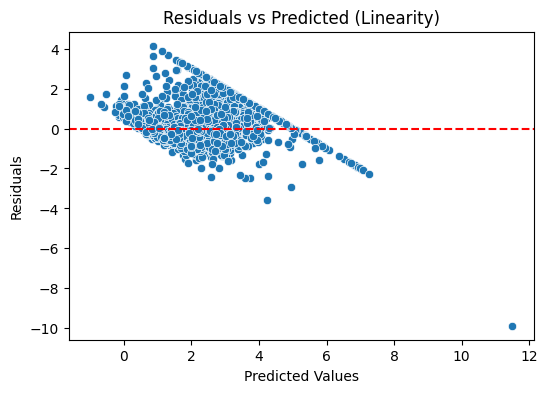

👉 Should look random (no curve)

🔹 Homoscedasticity Check


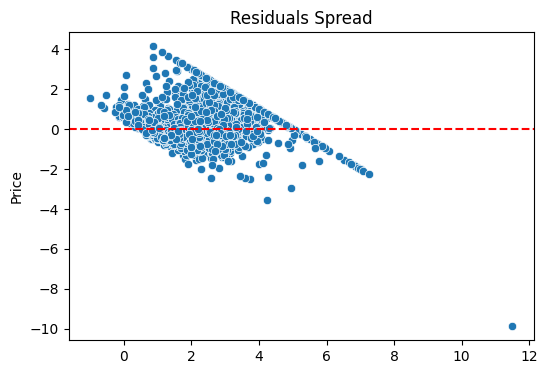

👉 Spread should be constant (no funnel shape)

🔹 Normality Check


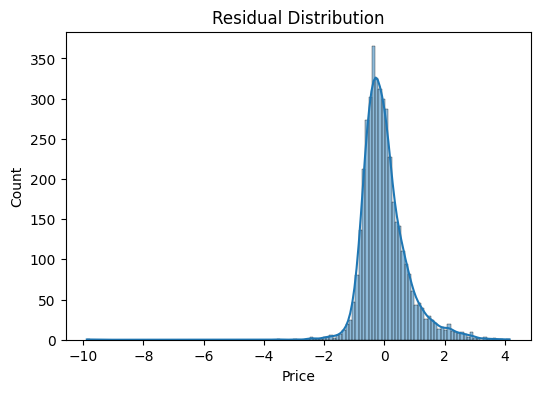

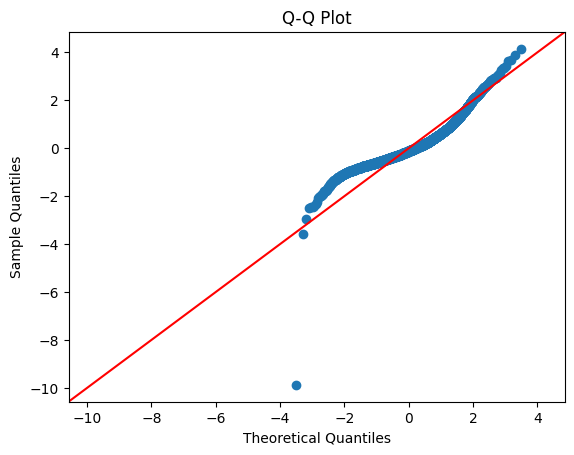

Shapiro Test p-value: 1.7414798558477595e-45
❌ Residuals are NOT normal

🔹 Independence Check
Durbin-Watson: 2.040741738727076
✅ Errors are independent

🔹 Multicollinearity Check (VIF)
   Feature        VIF
0        0   2.577906
1        1   1.262608
2        2  11.238447
3        3   9.627185
4        4   1.176137
5        5   1.037770
6        6   9.726584
7        7   9.357793
❌ High multicollinearity detected


In [107]:
check_regression_assumptions(X_test, y_test, model)

In [ ]:
# pickling

import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
import pickle
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ===============================
# 📥 Load Dataset (REAL DATA)
# ===============================
data = fetch_california_housing()

X = data.data   # 8 features
y = data.target

# Train-test split (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🤖 Load Trained Model
# ===============================
model = pickle.load(open('model.pkl', 'rb'))

# ===============================
# 🔮 Sample Prediction (8 features)
# ===============================
sample = np.array([[8.3252, 41, 6.9841, 1.0238, 322, 2.5555, 37.88, -122.23]])

# Input validation
if sample.shape[1] != 8:
    raise ValueError("❌ Input must have exactly 8 features")

prediction = model.predict(sample)
print("🏠 Predicted House Price:", prediction[0])

# ===============================
# 📊 MODEL PERFORMANCE
# ===============================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n📊 Model Performance Metrics:")
print(f"R2 Score      : {r2:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")

# ===============================
# 🧠 SMART PERFORMANCE SUMMARY
# ===============================
def model_quality(r2):
    if r2 > 0.85:
        return "🔥 Excellent"
    elif r2 > 0.65:
        return "⚡ Good"
    elif r2 > 0.4:
        return "⚠️ Average"
    else:
        return "❌ Poor"

print("\n🧠 Model Insight:", model_quality(r2))

🏠 Predicted House Price: 83.99806506879284

📊 Model Performance Metrics:
R2 Score      : -4214.2918
MAE           : 74.2380
MSE           : 5523.7562
RMSE          : 74.3220

🧠 Model Insight: ❌ Poor
